# Cyclistic Bike-Share Case Study


## Author's Note

 This is my first end-to-end data analysis project created as part of my journey into data analytics.

 My goal was to independently complete the entire analytical workflow using real-world data, from data collection and cleaning to exploratory data analysis, visualization, and business recommendations.

To make the project as realistic as possible, I downloaded the original monthly Cyclistic datasets directly from the official Divvy website instead of using a pre-prepared dataset.

 I welcome any feedback or suggestions for improvement.

# 1. ASK


## Business Problem

The bike-sharing company aims to increase the number of annual memberships, as annual members are more profitable than casual riders. Therefore, the main objective is to understand how casual riders use Cyclistic bikes and identify opportunities to convert them into annual members.

## Business Task

My responsibility is to analyze the riding behavior of casual riders and annual members by identifying key patterns and relationships in the data. The goal is to better understand how both customer groups use Cyclistic bikes.

## Key Business Question

How do annual members and casual riders use Cyclistic bikes differently?

## Stakeholders

- Lily Moreno (Director of Marketing)
- Cyclistic Marketing Analytics Team
- Cyclistic Executive Team

# 2. Prepare


**In this phase, the dataset is imported, inspected, and prepared for further analysis. Since the official Divvy data is provided as separate monthly files, the datasets must first be verified and combined into a single DataFrame.**

## Data Source

This analysis uses Cyclistic's historical trip data covering the 2025 calendar year (January–December 2025). The dataset provides detailed information about ride duration, bike type, ride timing, and membership status, making it suitable for answering the main business question.

The data is publicly available and has been made available by Motivate International Inc. under its data license.

**Official dataset:** https://divvy-tripdata.s3.amazonaws.com/index.html

**Data license:** https://divvybikes.com/data-license-agreement

The original dataset is not included in this notebook. To reproduce the analysis, please download the data from the official Divvy website.

## Import Libraries and Load Data

In [1]:
# Import required libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Display available dataset files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/karolcecua/case-study/case_study/202504-divvy-tripdata/202504-divvy-tripdata.csv
/kaggle/input/datasets/karolcecua/case-study/case_study/202505-divvy-tripdata/202505-divvy-tripdata.csv
/kaggle/input/datasets/karolcecua/case-study/case_study/202507-divvy-tripdata/202507-divvy-tripdata.csv
/kaggle/input/datasets/karolcecua/case-study/case_study/202508-divvy-tripdata (1)/202508-divvy-tripdata.csv
/kaggle/input/datasets/karolcecua/case-study/case_study/202506-divvy-tripdata/202506-divvy-tripdata.csv
/kaggle/input/datasets/karolcecua/case-study/case_study/202510-divvy-tripdata/202510-divvy-tripdata.csv
/kaggle/input/datasets/karolcecua/case-study/case_study/202502-divvy-tripdata/202502-divvy-tripdata.csv
/kaggle/input/datasets/karolcecua/case-study/case_study/202512-divvy-tripdata/202512-divvy-tripdata.csv
/kaggle/input/datasets/karolcecua/case-study/case_study/202503-divvy-tripdata/202503-divvy-tripdata.csv
/kaggle/input/datasets/karolcecua/case-study/case_study/2025

## Schema Validation

**Before merging all monthly datasets, it is necessary to verify that they share the same schema, including column names and data types.**

In [2]:
import os
import pandas as pd

# 1. Find all CSV files
csv_paths = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith(".csv"):
            csv_paths.append(os.path.join(dirname, filename))

# 2. Load the first file as the reference
reference_df = pd.read_csv(csv_paths[0])
reference_columns = list(reference_df.columns)
reference_dtypes = list(reference_df.dtypes)

print("Reference (columns):")
print(reference_columns)
print("Reference (dtypes):")
print(reference_dtypes)

# 3. Check each remaining file
for path in csv_paths[1:]:
    current_df = pd.read_csv(path)
    current_columns = list(current_df.columns)
    current_dtypes = list(current_df.dtypes)

    if current_columns == reference_columns:
        print(path, "-> OK, columns match")
    else:
        print(path, "-> WARNING, columns differ!")
        print("   reference:", reference_columns)
        print("   this file:", current_columns)

    if current_dtypes == reference_dtypes:
        print(path, "-> OK, dtypes match")
    else:
        print(path, "-> WARNING, dtypes differ!")
        print("   reference:", reference_dtypes)
        print("   this file:", current_dtypes)

Reference (columns):
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']
Reference (dtypes):
[dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('O')]
/kaggle/input/datasets/karolcecua/case-study/case_study/202505-divvy-tripdata/202505-divvy-tripdata.csv -> OK, columns match
/kaggle/input/datasets/karolcecua/case-study/case_study/202505-divvy-tripdata/202505-divvy-tripdata.csv -> OK, dtypes match
/kaggle/input/datasets/karolcecua/case-study/case_study/202507-divvy-tripdata/202507-divvy-tripdata.csv -> OK, columns match
/kaggle/input/datasets/karolcecua/case-study/case_study/202507-divvy-tripdata/202507-divvy-tripdata.csv -> OK, dtypes match
/kaggle/input/datasets/karolcecua/case-study/case_study/202508-divvy-tripdata (1

**All monthly datasets have the same structure, column names, and data types.**

## Merge Monthly Datasets

In [3]:
dfs = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith(".csv"):
            path = os.path.join(dirname, filename)
            temp_df = pd.read_csv(path)
            dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)

**The official Divvy data is provided as separate monthly files. To analyze riding behavior over an entire year and identify seasonal patterns, all monthly datasets were merged into a single DataFrame.**

## Inspect the Combined Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5552994 entries, 0 to 5552993
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 550.8+ MB


In [5]:
print(df.shape)
df.head()

(5552994, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,AF3863596DF9D94B,classic_bike,2025-04-27 14:29:34.619,2025-04-27 14:36:23.584,Troy St & Elston Ave,15631,Richmond St & Diversey Ave,15645,41.945244,-87.706650,41.931902,-87.701195,member
1,8B38081EBE918800,electric_bike,2025-04-23 17:48:51.863,2025-04-23 17:59:06.015,Wabash Ave & Adams St,KA1503000015,Green St & Madison St,TA1307000120,41.879472,-87.625689,41.881859,-87.649264,member
2,1C7F1DE826BBBC8D,electric_bike,2025-04-05 17:55:30.845,2025-04-05 18:05:40.032,Damen Ave & Cortland St,13133,California Ave & Fletcher St,15642,41.915983,-87.677335,41.938429,-87.698008,member
3,CAD23D69A79A6C3B,classic_bike,2025-04-03 08:22:04.493,2025-04-03 08:32:06.099,Clark St & Elm St,TA1307000039,Orleans St & Merchandise Mart Plaza,TA1305000022,41.902973,-87.631280,41.888243,-87.636390,member
4,BE241E601482E0AB,electric_bike,2025-04-15 06:09:55.293,2025-04-15 06:19:58.942,Western Ave & Walton St,KA1504000103,Damen Ave & Charleston St,13288,41.898418,-87.686596,41.920082,-87.677855,member


**All twelve monthly datasets were successfully merged into a single DataFrame containing one year of ride data.**


# 3. Process

**Before performing the analysis, the dataset must be cleaned and prepared. In this phase, I verify data quality, inspect missing values and duplicates, create additional features, and ensure that the dataset is ready for reliable analysis.**

## Convert Date Columns to Datetime Format

In [6]:
df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])
df.dtypes

ride_id                       object
rideable_type                 object
started_at            datetime64[ns]
ended_at              datetime64[ns]
start_station_name            object
start_station_id              object
end_station_name              object
end_station_id                object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
dtype: object

**Both date columns were successfully converted to the datetime format, enabling time-based calculations and feature engineering.**

## Inspect Missing Values

In [7]:
df.isnull().sum()

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1184673
start_station_id      1184673
end_station_name      1243305
end_station_id        1243305
start_lat                   0
start_lng                   0
end_lat                  5535
end_lng                  5535
member_casual               0
dtype: int64

In [8]:
missing_rows = df[df.isnull().any(axis=1)]

missing_rows.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
50,55747F7E402C9543,electric_bike,2025-04-13 18:27:28.887,2025-04-13 18:31:33.890,Troy St & Elston Ave,15631,NaN,NaN,41.945244,-87.70665,41.940000,-87.700000,member
792,EFBEEA2C5AECCD5C,electric_bike,2025-04-27 16:29:10.824,2025-04-27 16:50:27.630,NaN,NaN,Halsted St & 18th St,13099,41.910000,-87.66000,41.857506,-87.645991,member
793,F7F70CC9F86BB553,electric_bike,2025-04-03 15:42:42.960,2025-04-03 15:59:03.113,NaN,NaN,Halsted St & 18th St,13099,41.910000,-87.65000,41.857506,-87.645991,member
794,DAF052372FE0FCA0,electric_bike,2025-04-17 12:24:00.732,2025-04-17 12:31:10.069,NaN,NaN,Halsted St & 18th St,13099,41.860000,-87.63000,41.857506,-87.645991,member
795,ADD66B84FDB951C0,electric_bike,2025-04-16 19:05:40.710,2025-04-16 19:13:13.333,NaN,NaN,Ogden Ave & Race Ave,13194,41.870000,-87.67000,41.891795,-87.658751,member


In [9]:
# Check whether missing values follow a consistent pattern

print(df[
    df["start_station_name"].isna() &
    df["end_station_name"].notna()
].shape)

print(df[
    df["start_station_name"].notna() &
    df["end_station_name"].notna()
].shape)

(616435, 13)
(3693254, 13)


In [10]:
missing_rows["rideable_type"].value_counts()

rideable_type
electric_bike    1854107
classic_bike        5633
Name: count, dtype: int64


**Missing values were found mainly in station-related columns and some destination coordinates.**

**Further inspection showed that the missing values follow a consistent pattern: they are almost entirely correlated with electric bikes. In some cases, only the destination station information is missing, while in others both station names are unavailable despite the presence of geographic coordinates.**

**Since the analysis focuses on riding behavior rather than station locations, these missing values are unlikely to affect the main business question. Therefore, they were retained in the dataset.**

## Check Duplicate Records

In [11]:
print(df.duplicated().sum())
print(df['ride_id'].duplicated().sum())

0
0


**No duplicate records were found in the dataset. Therefore, no duplicate removal was required.**

## Create Additional Features and inspect new fields

In [12]:
pd.set_option("display.float_format", "{:.2f}".format)
df['ride_length']=((df['ended_at']-df['started_at']).dt.total_seconds()/3600)
df['start_hour']=df['started_at'].dt.hour
df['end_hour']=df['ended_at'].dt.hour
df['day_of_week']=df['started_at'].dt.strftime('%a')
df['month']=df['started_at'].dt.strftime('%b')

df[[
    "ride_length",
    "start_hour",
    "end_hour",
    "day_of_week",
    "month"
]].head()

,ride_length,start_hour,end_hour,day_of_week,month
0,0.11,14,14,Sun,Apr
1,0.17,17,17,Wed,Apr
2,0.17,17,18,Sat,Apr
3,0.17,8,8,Thu,Apr
4,0.17,6,6,Tue,Apr


**To facilitate further analysis, several new variables were created based on the original timestamp columns.**

In [13]:
(df["ride_length"] <= 0).sum()

np.int64(29)

In [14]:
df = df[df["ride_length"] > 0]
df["ride_length"].describe()

count   5552965.00
mean          0.27
std           0.92
min           0.00
25%           0.09
50%           0.16
75%           0.28
max          26.25
Name: ride_length, dtype: float64

**A total of 29 records with negative or zero-duration rides were identified. Since a trip cannot have a negative duration, these observations were considered invalid and removed from the dataset.**

In [15]:
# Number of rides by bike type
df["rideable_type"].value_counts()

rideable_type
electric_bike    3604936
classic_bike     1948029
Name: count, dtype: int64

In [16]:
# Number of rides by membership type
df["member_casual"].value_counts()

member_casual
member    3553477
casual    1999488
Name: count, dtype: int64

In [17]:
# Percent of rides by membership type
df["member_casual"].value_counts(normalize=True) * 100

member_casual
member   63.99
casual   36.01
Name: proportion, dtype: float64

**Casual riders represent 35% of total rides — not a marginal segment, but a large enough base that even a modest conversion rate could meaningfully grow annual memberships, which finance has identified as the more profitable customer type.**

# 4. Analyze

**The following analysis explores key differences between casual riders and annual members. Each visualization is designed to answer the main business question and identify behavioral patterns that may support future marketing decisions.**

## Ride Duration Analysis

In [18]:
df.groupby(['member_casual'])['ride_length'].describe()

,count,mean,std,min,25%,50%,75%,max
member_casual,,,,,,,,
casual,1999488.00,0.38,1.36,0.00,0.11,0.19,0.35,26.25
member,3553477.00,0.21,0.52,0.00,0.08,0.14,0.24,25.00


In [19]:
df["ride_length"].quantile([0.90, 0.95, 0.99, 0.999])

0.90    0.47
0.95    0.66
0.99    1.48
1.00   24.29
Name: ride_length, dtype: float64

**99 percent of users ride less than 1.5 hours.**

In [20]:

df[df["ride_length"] > 2].groupby("member_casual").size()

member_casual
casual    24066
member     7481
dtype: int64

**Casual riders are significantly more likely to keep bikes rented for more than two hours than annual members.**

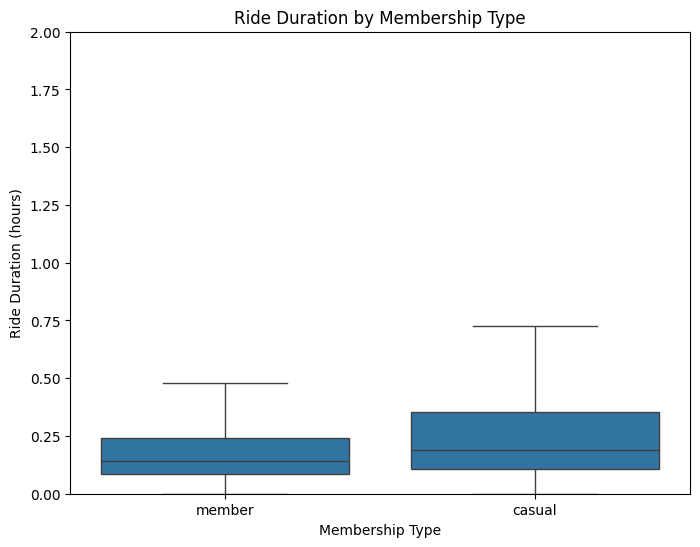

In [21]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="member_casual",
    y="ride_length",
    showfliers=False
)

plt.title("Ride Duration by Membership Type")
plt.xlabel("Membership Type")
plt.ylabel("Ride Duration (hours)")

plt.ylim(0,2)

plt.show()

**Casual riders tend to keep bicycles rented for longer periods than annual members. This is reflected in both the average and median rental duration.**

## Bike Type Preferences

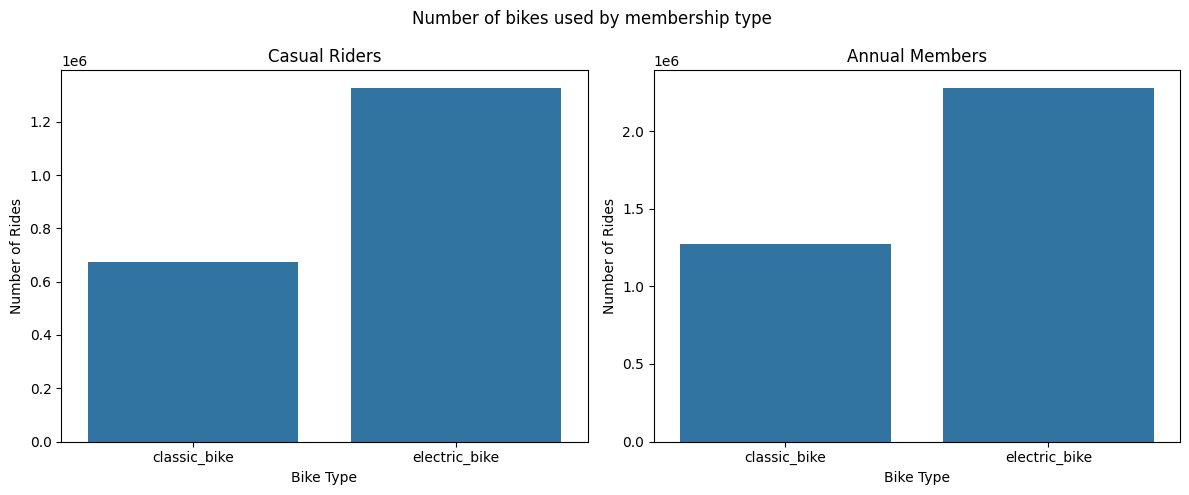

In [22]:
bike_type=df.groupby(['member_casual','rideable_type']).size().reset_index(name='number_of_rides')


casual = bike_type[bike_type["member_casual"]=="casual"]


member=bike_type[bike_type['member_casual']=='member']


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.barplot(
    data=casual,
    x="rideable_type",
    y="number_of_rides",
   
)

plt.title("Casual Riders")
plt.xlabel("Bike Type")
plt.ylabel("Number of Rides")

plt.subplot(1,2,2)
sns.barplot(
    data=member,
    x="rideable_type",
    y="number_of_rides",
    
)

plt.title("Annual Members")
plt.xlabel("Bike Type")
plt.ylabel("Number of Rides")


plt.suptitle('Number of bikes used by membership type ')
plt.tight_layout()
plt.show()



**Both casual riders and annual members use electric bikes almost twice as often as classic bikes.**

## Riding Patterns Throughout the Day

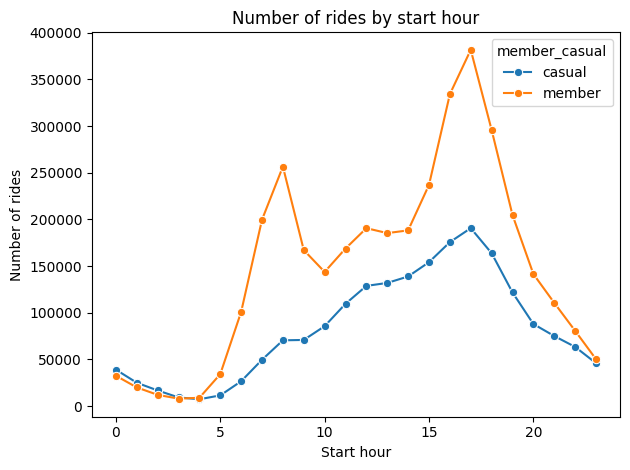

In [23]:
hourly = (
    df.groupby(['member_casual', 'start_hour'])
      .size()
      .reset_index(name='rides')
)


sns.lineplot(
    data=hourly,
    x='start_hour',
    y='rides',
    hue='member_casual',
    marker="o"
)

plt.title("Number of rides by start hour")
plt.xlabel("Start hour")
plt.ylabel("Number of rides")

plt.tight_layout()
plt.show()

**The riding pattern of annual members shows two distinct peaks during the morning and late afternoon, suggesting commuting behavior. Casual riders display a more gradual increase in activity throughout the day, with the highest number of rides occurring in the late afternoon**

**This pattern suggests that annual members frequently use bikes for commuting to and from work, whereas casual riders are more likely to use bikes for leisure activities later in the day.**

## Weekly Riding Patterns

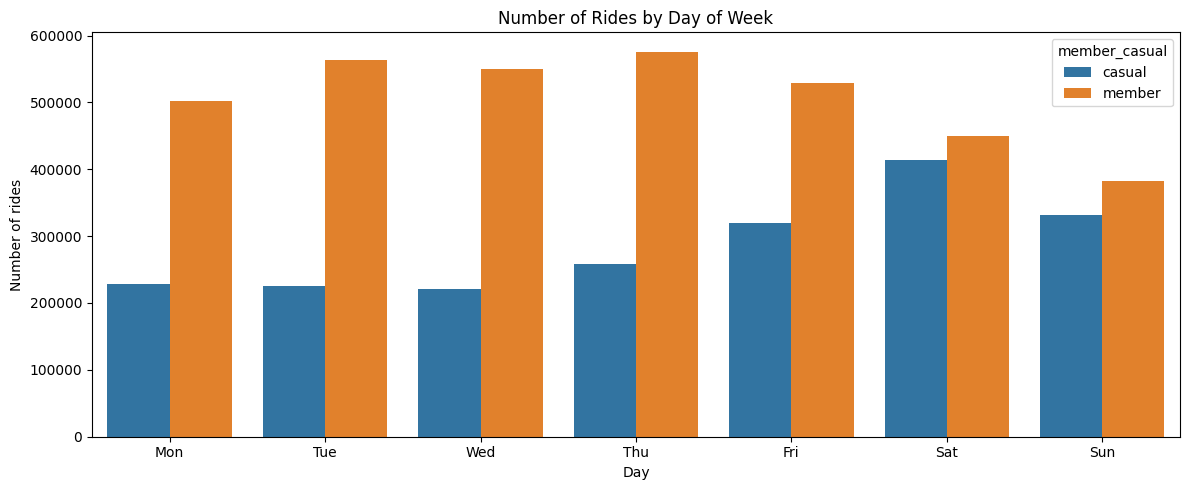

In [24]:
weekday=df.groupby(['member_casual','day_of_week']).size().reset_index(name='number_of_rides')

weekday_order = [
    "Mon", "Tue", "Wed",
    "Thu", "Fri", "Sat", "Sun"
]

plt.figure(figsize=(12,5))

sns.barplot(data=weekday, x='day_of_week', y='number_of_rides', hue='member_casual', order=weekday_order)
plt.title('Number of Rides by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of rides')

plt.tight_layout()
plt.show()

**Annual members maintain a relatively stable riding pattern throughout the working week, followed by a noticeable decrease during the weekend. In contrast, casual riders become significantly more active on Saturdays and Sundays, suggesting that they primarily use bikes for leisure and recreational purposes.**

## Seasonal riding patterns

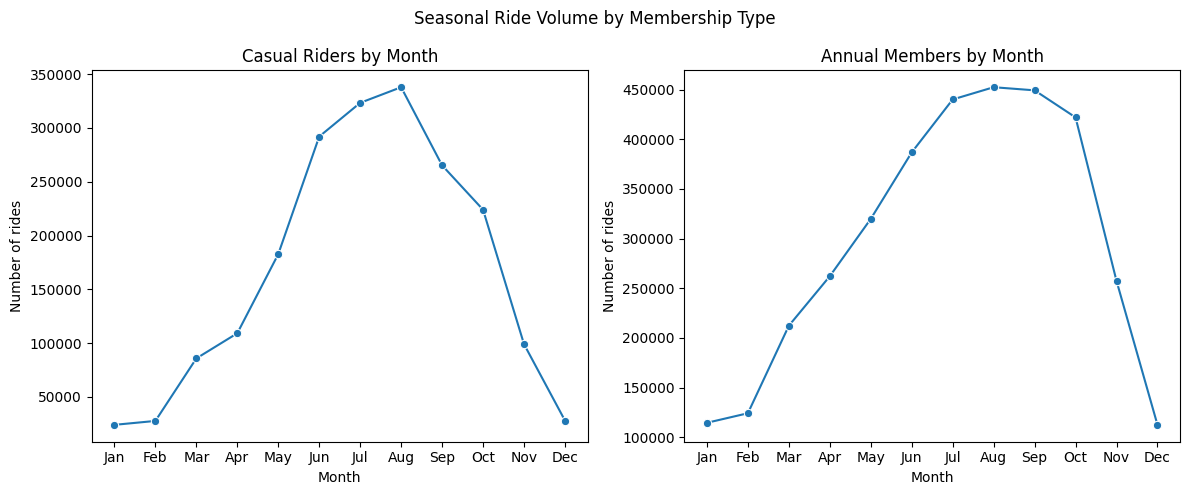

In [25]:
month=df.groupby(['member_casual','month']).size().reset_index(name='number_of_rides')
month_order = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

month["month"] = pd.Categorical(
    month["month"],
    categories=month_order,
    ordered=True
)

month = month.sort_values("month")

casual = month[month["member_casual"] == "casual"]

member = month[month["member_casual"] == "member"]


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.lineplot(data=casual, x='month', y='number_of_rides',marker='o',sort=False)

plt.title('Casual Riders by Month')
plt.xlabel('Month')
plt.ylabel('Number of rides')


plt.subplot(1,2,2)

sns.lineplot(data=member, x='month', y='number_of_rides',marker='o',sort=False)

plt.title('Annual Members by Month')
plt.xlabel('Month')
plt.ylabel('Number of rides')

plt.suptitle("Seasonal Ride Volume by Membership Type")
plt.tight_layout()
plt.show()


**Ride activity increases steadily from spring and peaks during the summer months for both groups. However, annual members maintain a more stable level of bike usage throughout the year, whereas casual riders are considerably more affected by seasonality.**

# 5. Share and Act

**After completing the exploratory data analysis, several key differences between casual riders and annual members were identified. The following findings summarize the most important insights that will be used to formulate business recommendations.**

## Findings

**Longer Ride Duration Among Casual Riders**



The analysis showed that 99% of all rides lasted less than 1.5 hours. However, casual riders consistently rented bicycles for longer periods than annual members, suggesting different riding purposes between the two groups.

**Preference for Electric Bikes**

Electric bikes were used almost twice as often as classic bikes by both casual riders and annual members. This indicates that electric bikes are the preferred option regardless of membership type.

**Different Daily Riding Patterns**

Annual members displayed two noticeable peaks during the morning and late afternoon, suggesting regular commuting to work or school. In contrast, casual riders showed a gradual increase in activity throughout the day, reaching the highest number of rides in the late afternoon.

**Weekday vs Weekend Usage**

Annual members recorded the highest number of rides from Monday to Friday, whereas casual riders reached their highest activity during weekends. This difference suggests that annual members primarily use bicycles for transportation, while casual riders are more likely to ride for leisure.

**Seasonal Riding Trends**

Both groups became significantly more active during the summer months. However, casual riders were much more affected by seasonal changes, while annual members maintained a more stable level of activity throughout the year.

## Recommendations

**1. Launch marketing campaigns before the summer season.**

Since casual rider activity increases rapidly from late spring onwards, promoting annual memberships before the summer season may encourage frequent seasonal riders to subscribe.

**2. Focus promotional campaigns on weekends.**

Weekends represent the period with the highest casual rider activity, making them an ideal opportunity to advertise the benefits of an annual membership.

**3. Target frequent casual riders with personalized membership offers.**

The analysis suggests that not every casual rider is an ideal candidate for an annual membership. Marketing efforts should focus on riders who frequently rent bikes or display riding patterns similar to annual members, as they are more likely to benefit from a subscription.

## Final conclusion

**The analysis identified clear behavioral differences between casual riders and annual members. Annual members appear to use Cyclistic bikes primarily for everyday transportation, while casual riders mainly use them for leisure and recreational purposes. Understanding these differences allows Cyclistic to better target marketing campaigns and develop strategies aimed at converting suitable casual riders into annual members.**